# Benchmark Plots for Sphinx Documentation

This notebook generates benchmark plots for FP-QGPU vs Qiskit Aer and is included directly in the Sphinx docs so plots appear in the rendered documentation.

## 1. Set Up Sphinx and Notebook Extensions

This project already uses MyST-NB (`myst_nb`) in Sphinx.

If you need to install dependencies in a fresh environment, run:

```bash
uv add sphinx myst-nb matplotlib jupyter qiskit qiskit-aer pytest pytest-benchmark
```

The next cell checks versions used by this notebook.

In [1]:
import matplotlib
import numpy as np
import qiskit
import qiskit_aer

print("matplotlib", matplotlib.__version__)
print("numpy", np.__version__)
print("qiskit", qiskit.__version__)
print("qiskit_aer", qiskit_aer.__version__)

matplotlib 3.10.8
numpy 2.4.3
qiskit 2.3.1
qiskit_aer 0.17.2


## 2. Create a Jupyter Notebook That Generates Plots

This cell runs benchmark cases across qubits, computes mean runtime for both simulators, computes the ratio `own/aer`, and generates inline plots.

({'00': 521, '11': 503}, Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2)))
[['h', [0], array([[ 0.70710678+0.j,  0.70710678+0.j],
       [ 0.70710678+0.j, -0.70710678+0.j]])], ['cx', [0, 1], array([[1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j],
       [0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j],
       [0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j]])]]


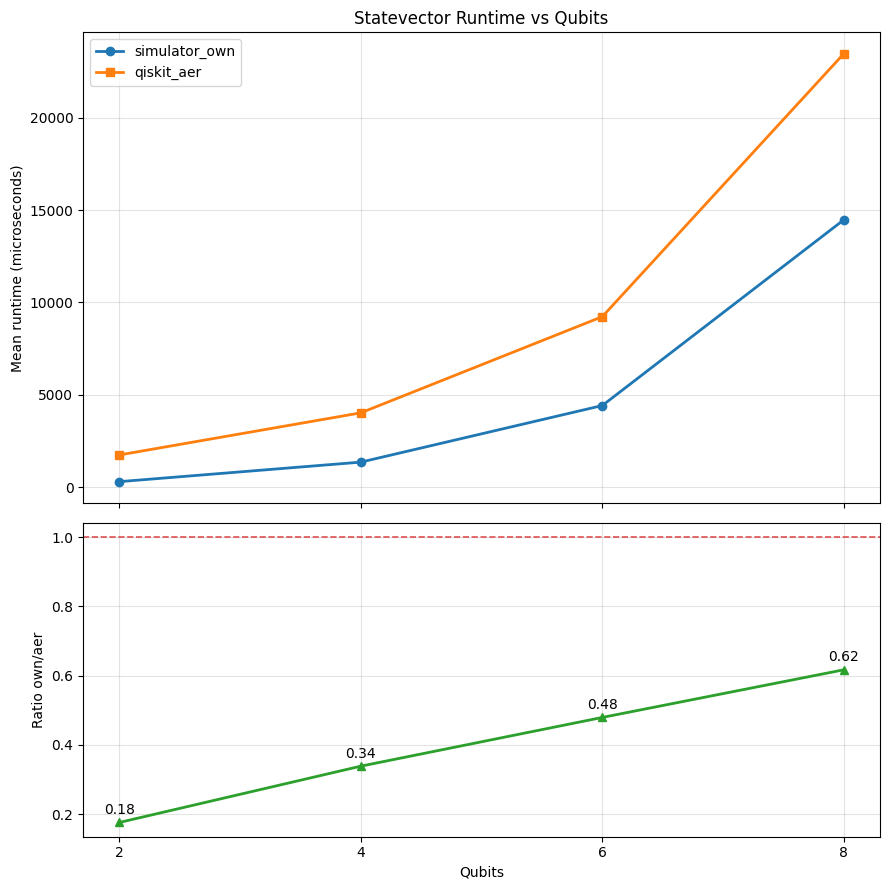

Saved static image to: ..\_static\benchmark_runtime_vs_qubits.png


In [2]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
from qiskit import transpile
from qiskit.circuit.random import random_circuit
from qiskit_aer import AerSimulator

from fp_qgpu.simulator import simulator_own


def run_aer_statevector(simulator, circuit):
    result = simulator.run(circuit, shots=1).result()
    return np.asarray(result.get_statevector(circuit), dtype=complex)


def assert_equivalent_up_to_global_phase(reference, candidate, atol=1e-12):
    idx = int(np.argmax(np.abs(reference)))
    phase = reference[idx] / candidate[idx]
    assert np.allclose(reference, candidate * phase, atol=atol)


qubit_cases = [2, 4, 6, 8]
rounds = 20
warmup_rounds = 2

mean_own_s = []
mean_aer_s = []
ratio_own_div_aer = []

for num_qubits in qubit_cases:
    depth = max(8, num_qubits * 3)
    qc = random_circuit(num_qubits, depth, measure=False, seed=200 + num_qubits)
    qc_own = transpile(qc, basis_gates=["u", "cx"], optimization_level=0)

    simulator = AerSimulator(method="statevector")
    qc_aer = qc_own.copy()
    qc_aer.save_statevector()
    qc_aer = transpile(qc_aer, simulator, optimization_level=0)

    state_own = simulator_own(qc_own)
    state_aer = run_aer_statevector(simulator, qc_aer)
    assert_equivalent_up_to_global_phase(state_aer, state_own)

    own_times = []
    aer_times = []

    for _ in range(warmup_rounds):
        simulator_own(qc_own)
        run_aer_statevector(simulator, qc_aer)

    for _ in range(rounds):
        t0 = perf_counter()
        simulator_own(qc_own)
        own_times.append(perf_counter() - t0)

        t0 = perf_counter()
        run_aer_statevector(simulator, qc_aer)
        aer_times.append(perf_counter() - t0)

    own_mean = float(np.mean(own_times))
    aer_mean = float(np.mean(aer_times))

    mean_own_s.append(own_mean)
    mean_aer_s.append(aer_mean)
    ratio_own_div_aer.append(own_mean / aer_mean)

fig, (ax_runtime, ax_ratio) = plt.subplots(
    2, 1, figsize=(9, 9), sharex=True, gridspec_kw={"height_ratios": [3, 2]}
)

ax_runtime.plot(
    qubit_cases,
    np.array(mean_own_s) * 1e6,
    marker="o",
    linewidth=2,
    label="simulator_own",
)
ax_runtime.plot(
    qubit_cases, np.array(mean_aer_s) * 1e6, marker="s", linewidth=2, label="qiskit_aer"
)
ax_runtime.set_ylabel("Mean runtime (microseconds)")
ax_runtime.set_title("Statevector Runtime vs Qubits")
ax_runtime.grid(True, alpha=0.35)
ax_runtime.legend()

ax_ratio.plot(
    qubit_cases, ratio_own_div_aer, marker="^", linewidth=2, color="tab:green"
)
ax_ratio.axhline(1.0, linestyle="--", linewidth=1.2, color="tab:red", alpha=0.8)
ax_ratio.set_xlabel("Qubits")
ax_ratio.set_ylabel("Ratio own/aer")
ax_ratio.set_xticks(qubit_cases)
ax_ratio.grid(True, alpha=0.35)

for q, r in zip(qubit_cases, ratio_own_div_aer):
    ax_ratio.annotate(
        f"{r:.2f}", (q, r), textcoords="offset points", xytext=(0, 6), ha="center"
    )

fig.tight_layout()

static_output = Path("../_static/benchmark_runtime_vs_qubits.png")
static_output.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(static_output, dpi=180)

plt.show()
print(f"Saved static image to: {static_output}")

## 3. Configure conf.py to Render Notebook Outputs

Use notebook support extensions and execution policy in `docs/conf.py`:

```python
extensions = [
    "sphinx.ext.autodoc",
    "sphinx.ext.napoleon",
    "sphinx.ext.viewcode",
    "sphinx.ext.intersphinx",
    "myst_nb",
]

html_static_path = ["_static"]
nb_execution_mode = "off"
```

With `nb_execution_mode = "off"`, outputs already saved in the notebook are rendered by Sphinx.

## 4. Add the Notebook to the Sphinx ToC

Add this notebook to a toctree entry in `docs/index.rst`:

```rst
.. toctree::
   :maxdepth: 2

   notebooks/benchmark_cases
```

This makes the notebook page part of the HTML build.

## 5. Build Documentation and Validate Plot Rendering

Use the next cell to run a docs build and verify that this notebook is rendered in HTML.

In [ ]:
import subprocess

build_cmd = [
    "c:/GitHub/FP-QGPU/.venv/Scripts/python.exe",
    "-m",
    "sphinx",
    "-b",
    "html",
    "docs",
    "docs/_build/html",
]

completed = subprocess.run(build_cmd, check=False, capture_output=True, text=True)
print("returncode:", completed.returncode)
print(completed.stdout.splitlines()[-5:])

## 6. Export Static Plot Files for Reuse (Optional)

This notebook already saves a reusable static image to:

- `docs/_static/benchmark_runtime_vs_qubits.png`

You can reference it from `.rst` pages with:

```rst
.. image:: _static/benchmark_runtime_vs_qubits.png
   :alt: Benchmark runtime and ratio over qubits
   :width: 85%
```